# Deep dive — Demand user theo **category**

Notebook bổ sung cho `eda_demand.ipynb` (cohort có ≥1 sự kiện tích cực).

**4 mũi khoan:**
1. Phễu session (`session_id`) — search → view → consider (dwell>30s) → contact
2. NLP `query` — giá, quận, keyword + heatmap nhu cầu + unmet demand
3. Lead scoring — `fact_post_contact_interactions` (chỉ `is_login = login`)
4. Độ tươi tin — `listing_age_days` lúc contact (join snapshot)

**Visualize:** chart trong **output** + **%** trên trục; PNG lưu `outputs/eda_demand_deep/`.

**RAM (M1 8GB):** DuckDB `memory_limit=2GB`; có cờ sample cho funnel/NLP.

In [1]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from unidecode import unidecode
except ImportError:
    unidecode = lambda s: s  # pip install unidecode

# --- RAM / sample ---
DUCKDB_MEMORY_LIMIT = "2GB"
DUCKDB_THREADS = 2
FUNNEL_SAMPLE_FRAC = 0.08   # None = full; 0.05–0.1 cho M1 8GB
QUERY_SAMPLE_FRAC = 0.15    # NLP trên pageview có query
LISTING_AGE_SAMPLE_FRAC = None  # join nhỏ hơn funnel; None thường OK

DATA_ROOT = Path.cwd().resolve()
OUT_DIR = DATA_ROOT / "outputs" / "eda_demand_deep"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EVENTS_GLOB = str(DATA_ROOT / "fact_user_events" / "*.parquet")
INTER_GLOB = str(DATA_ROOT / "fact_post_contact_interactions" / "*.parquet")
SNAP_GLOB = str(DATA_ROOT / "fact_listing_snapshot" / "*.parquet")

POSITIVE_TYPES = ("view_phone", "contact_chat", "other_interaction", "contact_zalo", "contact_sms")
pos_list = ", ".join(repr(x) for x in POSITIVE_TYPES)

CAT_META = pd.DataFrame([
    (1010, "Phòng trọ / CH thuê"),
    (1020, "Căn hộ / chung cư"),
    (1030, "Nhà ở"),
    (1040, "Đất nền / TM"),
    (1050, "Dự án mới"),
], columns=["category", "category_name"])
CAT_ORDER = CAT_META["category"].tolist()
PALETTE = {1010: "#238b45", 1020: "#2171b5", 1030: "#6a51a3", 1040: "#cb181d", 1050: "#d94801"}

# Phân tích từng category; đổi list nếu chỉ focus thuê (vd. [1010])
CATEGORIES_TO_RUN = CAT_ORDER  # hoặc [1010]

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.02)


def pct_share(s: pd.Series) -> pd.Series:
    t = float(s.sum())
    return (s / t * 100.0) if t else s.astype(float)


def pct_row(df: pd.DataFrame) -> pd.DataFrame:
    rs = df.sum(axis=1).replace(0, np.nan)
    return df.div(rs, axis=0) * 100.0


def sample_clause(frac) -> str:
    return "" if frac is None else f"AND random() < {float(frac)}"


def show_and_save(name: str, **kwargs):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", **kwargs)
    plt.show()
    print("Saved", path)


def norm_query(q: str) -> str:
    if q is None or (isinstance(q, float) and np.isnan(q)):
        return ""
    t = unidecode(str(q).lower().strip())
    return re.sub(r"\s+", " ", t)


con = duckdb.connect(":memory:")
con.execute(f"PRAGMA memory_limit='{DUCKDB_MEMORY_LIMIT}'")
con.execute(f"PRAGMA threads={DUCKDB_THREADS}")

print("DATA_ROOT =", DATA_ROOT)
print("Categories:", CATEGORIES_TO_RUN)



DATA_ROOT = /Users/dothinh_3112/Downloads/Datathon_Data
Categories: [1010, 1020, 1030, 1040, 1050]


## Bối cảnh từ EDA tổng quan (`eda_demand`)

| Phát hiện | Gợi ý cho deep dive |
|-----------|---------------------|
| Demand user: **non-login >> login** | Mũi 1–2: **session_id** là chuẩn; mũi 3 chỉ login |
| Căn hộ (1020) thường volume lớn | So sánh phễu & query theo từng `category` |
| CVR event-level khác nhau theo phân khúc | Mũi 1 đo **session funnel** chính xác hơn |
| Top query tập trung vài cụm giá/khu vực | Mũi 2 heatmap quận × giá |

Chạy cell Setup trước, sau đó từng mũi khoan (có thể lâu với `FUNNEL_SAMPLE_FRAC=None`).

## Mũi 1 — Session funnel (theo `session_id` × `device` × `category`)

<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,device,total_sessions,search_sessions,view_sessions,consider_sessions,contact_sessions,pct_search,pct_view,pct_consider,pct_contact,view_to_contact_pct
0,MSite,282712,2600,125860,99535,221434,0.92,44.52,35.21,78.32,175.94
1,iOS,279214,30487,236800,221478,100344,10.92,84.81,79.32,35.94,42.38
2,Desktop,269388,2813,110777,92853,230405,1.04,41.12,34.47,85.53,207.99
3,Android,115545,6366,78975,75695,56362,5.51,68.35,65.51,48.78,71.37


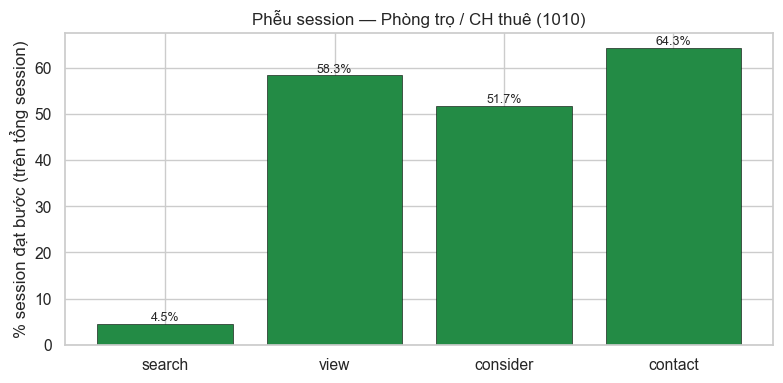

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/funnel_session_overall_1010.png


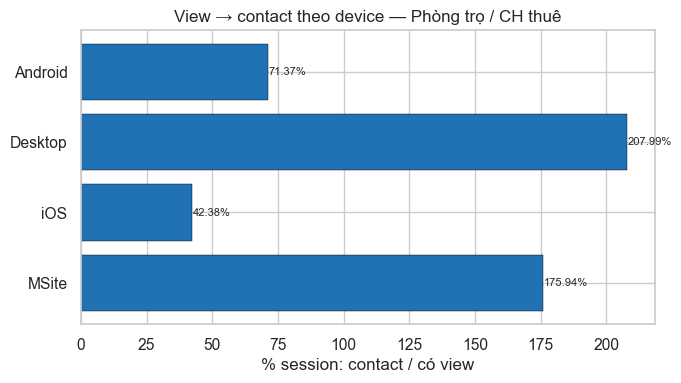

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/funnel_session_view_to_contact_device_1010.png
<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,device,total_sessions,search_sessions,view_sessions,consider_sessions,contact_sessions,pct_search,pct_view,pct_consider,pct_contact,view_to_contact_pct
0,iOS,648615,40045,544753,508960,260913,6.17,83.99,78.47,40.23,47.90
1,MSite,585622,5617,291085,241179,450734,0.96,49.71,41.18,76.97,154.85
2,Desktop,498423,4392,222501,186715,424293,0.88,44.64,37.46,85.13,190.69
3,Android,460794,16835,314611,302517,252331,3.65,68.28,65.65,54.76,80.20


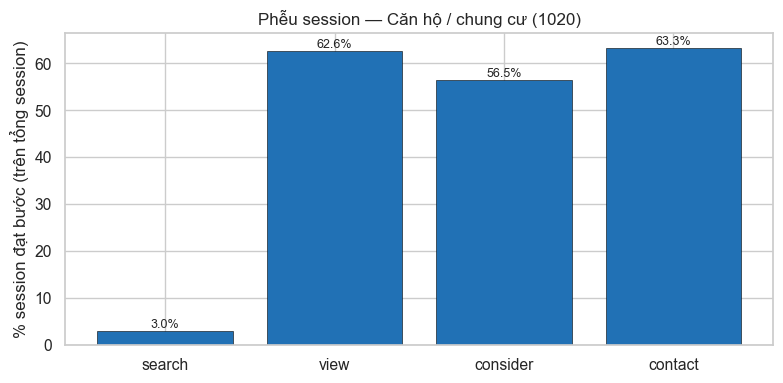

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/funnel_session_overall_1020.png


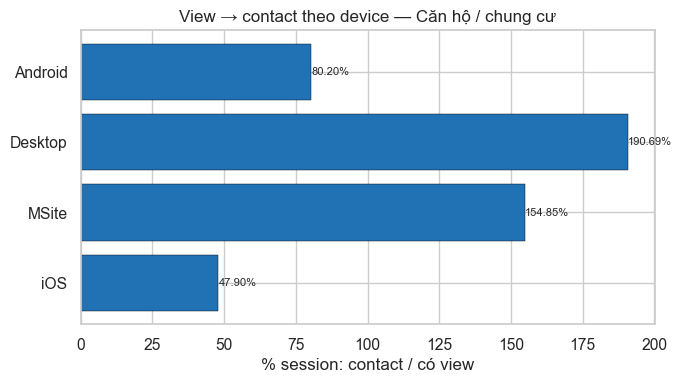

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/funnel_session_view_to_contact_device_1020.png
<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,device,total_sessions,search_sessions,view_sessions,consider_sessions,contact_sessions,pct_search,pct_view,pct_consider,pct_contact,view_to_contact_pct
0,iOS,112565,12969,99289,92672,31622,11.52,88.21,82.33,28.09,31.85
1,Desktop,85915,1291,39276,33824,68724,1.50,45.71,39.37,79.99,174.98
2,MSite,70285,1541,37044,30831,50020,2.19,52.71,43.87,71.17,135.03
3,Android,63578,5790,47147,45486,25646,9.11,74.16,71.54,40.34,54.40


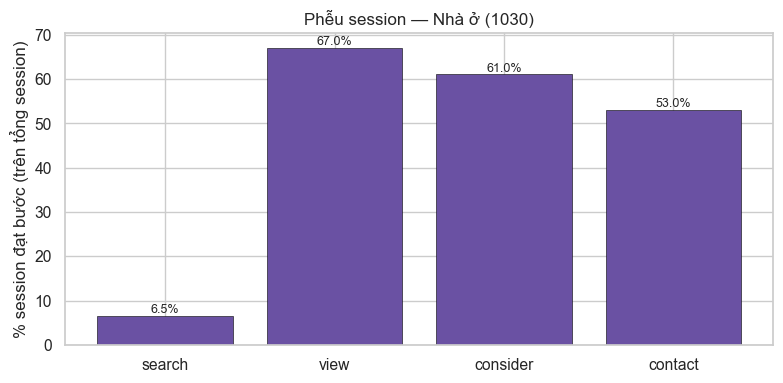

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/funnel_session_overall_1030.png


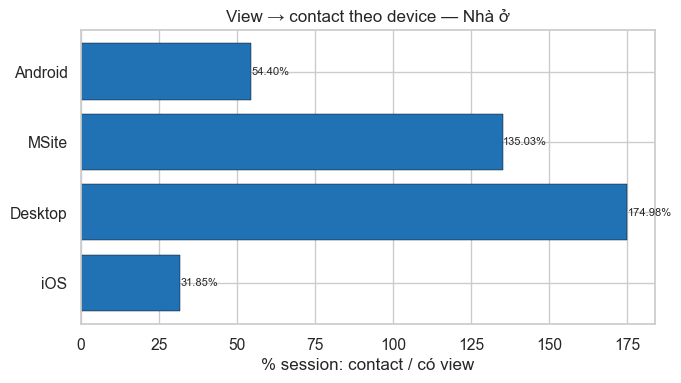

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/funnel_session_view_to_contact_device_1030.png
<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,device,total_sessions,search_sessions,view_sessions,consider_sessions,contact_sessions,pct_search,pct_view,pct_consider,pct_contact,view_to_contact_pct
0,Desktop,155476,1287,65530,52810,123255,0.83,42.15,33.97,79.28,188.09
1,iOS,150685,9149,130707,120634,41722,6.07,86.74,80.06,27.69,31.92
2,Android,135434,4184,86605,82953,64665,3.09,63.95,61.25,47.75,74.67
3,MSite,127319,949,58659,46270,92187,0.75,46.07,36.34,72.41,157.16


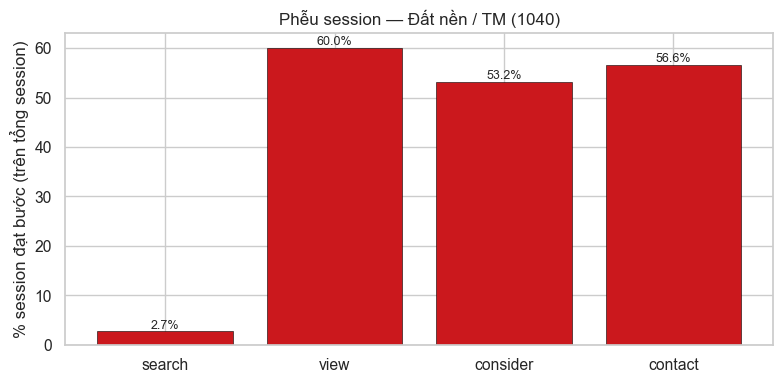

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/funnel_session_overall_1040.png


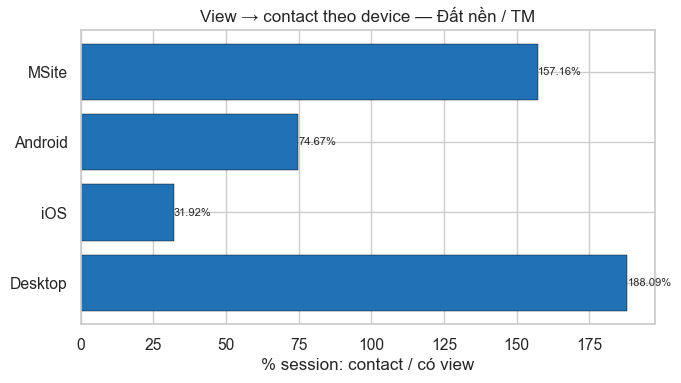

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/funnel_session_view_to_contact_device_1040.png
<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,device,total_sessions,search_sessions,view_sessions,consider_sessions,contact_sessions,pct_search,pct_view,pct_consider,pct_contact,view_to_contact_pct
0,iOS,387070,56406,352681,334635,120116,14.57,91.12,86.45,31.03,34.06
1,MSite,354902,5008,192440,162159,270212,1.41,54.22,45.69,76.14,140.41
2,Desktop,235591,2978,116830,100611,197929,1.26,49.59,42.71,84.01,169.42
3,Android,208265,19642,173500,167800,78655,9.43,83.31,80.57,37.77,45.33


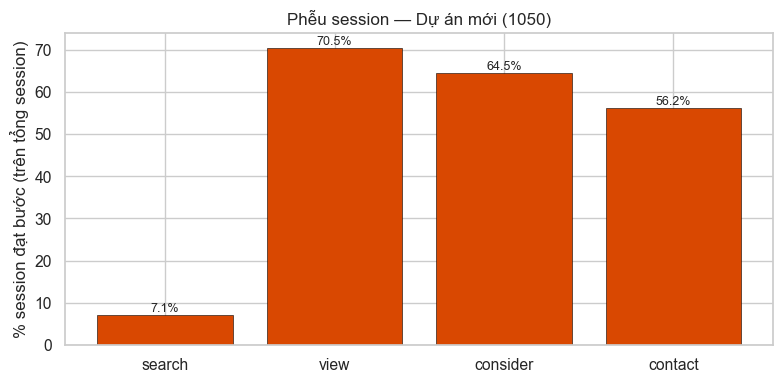

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/funnel_session_overall_1050.png


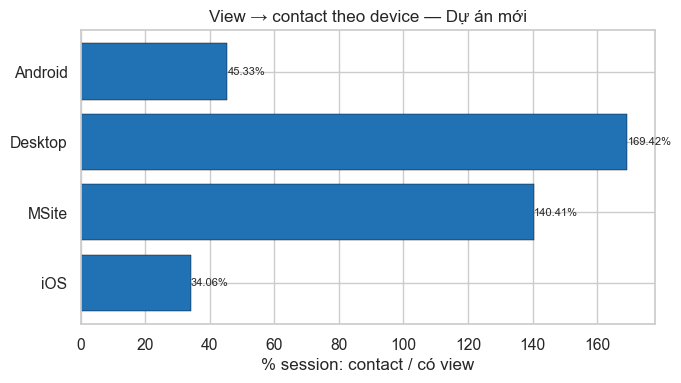

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/funnel_session_view_to_contact_device_1050.png


In [2]:
def session_funnel_for_category(cat: int) -> pd.DataFrame:
    where_sample = sample_clause(FUNNEL_SAMPLE_FRAC)
    return con.execute(
        f"""
        WITH session_events AS (
            SELECT
                session_id,
                device,
                MAX(CASE WHEN query IS NOT NULL AND TRIM(CAST(query AS VARCHAR)) <> '' THEN 1 ELSE 0 END) AS has_search,
                MAX(CASE WHEN event_type = 'pageview' THEN 1 ELSE 0 END) AS has_viewed_item,
                MAX(CASE WHEN event_type = 'pageview' AND COALESCE(dwell_time_sec, 0) > 30 THEN 1 ELSE 0 END) AS has_considered,
                MAX(CASE WHEN is_contact = 1 OR event_type IN ({pos_list}) THEN 1 ELSE 0 END) AS has_contacted
            FROM read_parquet(?)
            WHERE category = ?
              AND session_id IS NOT NULL
              {where_sample}
            GROUP BY session_id, device
        )
        SELECT
            device,
            COUNT(*)::BIGINT AS total_sessions,
            SUM(has_search)::BIGINT AS search_sessions,
            SUM(has_viewed_item)::BIGINT AS view_sessions,
            SUM(has_considered)::BIGINT AS consider_sessions,
            SUM(has_contacted)::BIGINT AS contact_sessions
        FROM session_events
        GROUP BY device
        ORDER BY total_sessions DESC
        """,
        [EVENTS_GLOB, cat],
    ).fetchdf()


def plot_session_funnel(fdf: pd.DataFrame, cat: int, cat_name: str):
    if fdf.empty:
        print("No data for", cat)
        return
    steps = ["search", "view", "consider", "contact"]
    step_cols = ["search_sessions", "view_sessions", "consider_sessions", "contact_sessions"]
    totals = fdf["total_sessions"].sum()
    display(fdf.assign(
        pct_search=lambda d: d["search_sessions"] / d["total_sessions"] * 100,
        pct_view=lambda d: d["view_sessions"] / d["total_sessions"] * 100,
        pct_consider=lambda d: d["consider_sessions"] / d["total_sessions"] * 100,
        pct_contact=lambda d: d["contact_sessions"] / d["total_sessions"] * 100,
        view_to_contact_pct=lambda d: np.where(
            d["view_sessions"] > 0, d["contact_sessions"] / d["view_sessions"] * 100, np.nan
        ),
    ).round(2))

  # Funnel tổng (gộp device) — % session đạt từng bước
    agg = {c: fdf[c].sum() for c in ["total_sessions"] + step_cols}
    vals = [agg[c] / agg["total_sessions"] * 100 for c in step_cols]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(steps, vals, color=PALETTE.get(cat, "#333"), edgecolor="black", linewidth=0.4)
    ax.set_ylabel("% session đạt bước (trên tổng session)")
    ax.set_title(f"Phễu session — {cat_name} ({cat})")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    show_and_save(f"funnel_session_overall_{cat}.png", dpi=150)

  # View → contact % theo device
    f2 = fdf.copy()
    f2["view_to_contact_pct"] = np.where(
        f2["view_sessions"] > 0, f2["contact_sessions"] / f2["view_sessions"] * 100, np.nan
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(f2["device"], f2["view_to_contact_pct"], color="#2171b5", edgecolor="black", linewidth=0.3)
    ax.set_xlabel("% session: contact / có view")
    ax.set_title(f"View → contact theo device — {cat_name}")
    for y, v in enumerate(f2["view_to_contact_pct"]):
        if pd.notna(v):
            ax.text(v + 0.1, y, f"{v:.2f}%", va="center", fontsize=8)
    show_and_save(f"funnel_session_view_to_contact_device_{cat}.png", dpi=150)


for cat in CATEGORIES_TO_RUN:
    name = CAT_META.loc[CAT_META["category"] == cat, "category_name"].iloc[0]
    print(Markdown(f"### Category **{cat}** — {name}"))
    sf = session_funnel_for_category(cat)
    plot_session_funnel(sf, cat, name)



## Mũi 2 — NLP `query` (giá, quận, keyword + heatmap + unmet demand)

Regex trên query đã chuẩn hóa (lowercase, bỏ dấu). Heatmap: **%** trong tổng query có cả quận + bucket giá.

<IPython.core.display.Markdown object>


,query,n,price_bucket,district,kw_type,pct
0,chung cư,4585,khong_ro_gia,khac,chung cu,29.540622
1,none,1496,khong_ro_gia,khac,khac,9.638554
2,căn hộ,1344,khong_ro_gia,khac,chung cu,8.659236
3,cho thuê căn hộ/chung cư ở tp hồ chí minh,1339,khong_ro_gia,khac,chung cu,8.627021
4,2 phòng ngủ,1237,khong_ro_gia,khac,khac,7.969847
5,2pn,1094,khong_ro_gia,khac,khac,7.048515
6,duplex,1002,khong_ro_gia,khac,khac,6.455770
7,căn hộ dịch vụ,846,khong_ro_gia,khac,chung cu,5.450680
8,studio,758,khong_ro_gia,khac,khac,4.883706
9,thuê chung cư,693,khong_ro_gia,khac,chung cu,4.464918


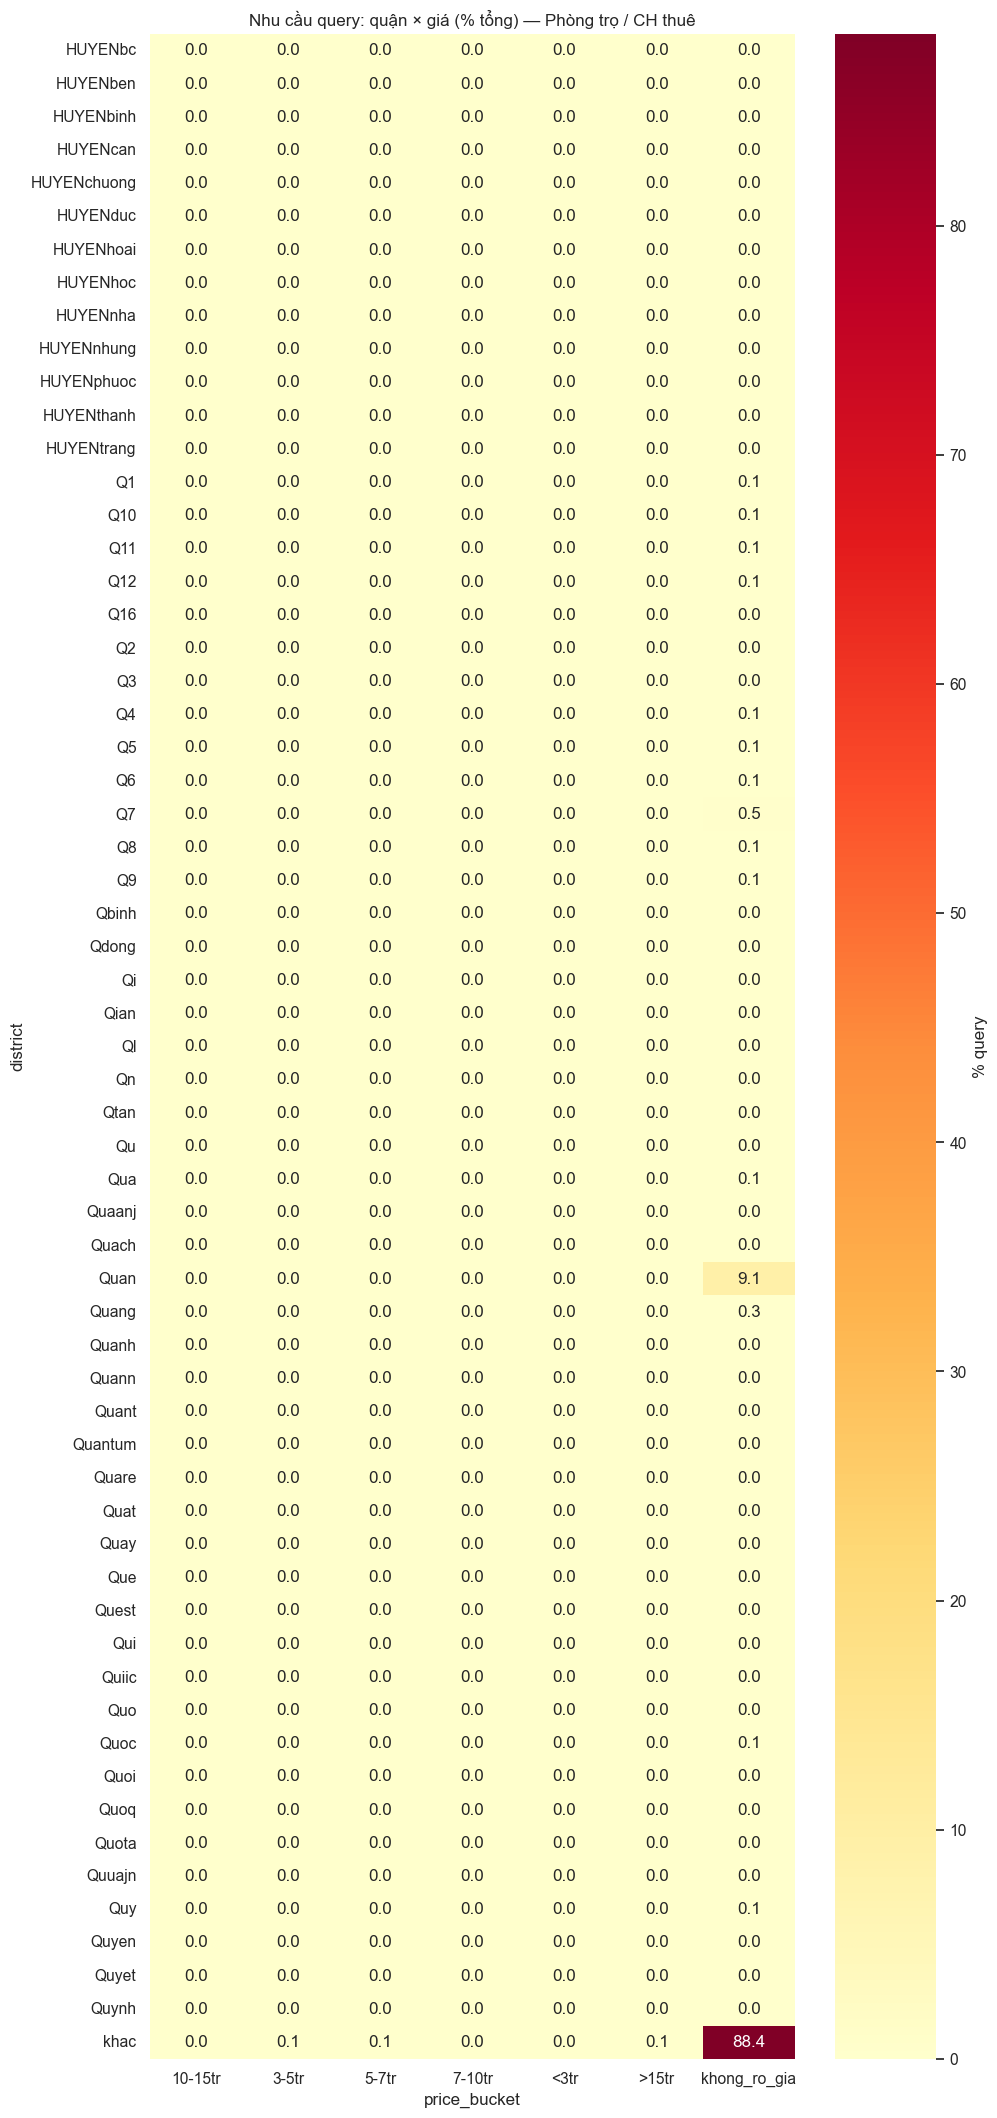

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/query_heatmap_district_price_1010.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,sessions_with_search,search_no_view,pct_unmet
0,42312,0,0.0


<IPython.core.display.Markdown object>


,query,n,price_bucket,district,kw_type,pct
0,nhà nguyên căn,7471,khong_ro_gia,khac,nha nguyen can,25.062060
1,none,3068,khong_ro_gia,khac,khac,10.291848
2,cho thuê nhà ở ở tp hồ chí minh,3034,khong_ro_gia,khac,khac,10.177793
3,nhà,2593,khong_ro_gia,khac,khac,8.698423
4,thuê nhà nguyên căn,2386,khong_ro_gia,khac,nha nguyen can,8.004025
5,nhà cho thuê,2227,khong_ro_gia,khac,khac,7.470647
6,nguyên căn,1937,khong_ro_gia,khac,nha nguyen can,6.497820
7,mua bán nhà ở ở tp hồ chí minh,1858,khong_ro_gia,khac,khac,6.232808
8,thuê nhà,1434,khong_ro_gia,khac,khac,4.810466
9,cho thuê nhà,1300,khong_ro_gia,khac,khac,4.360953


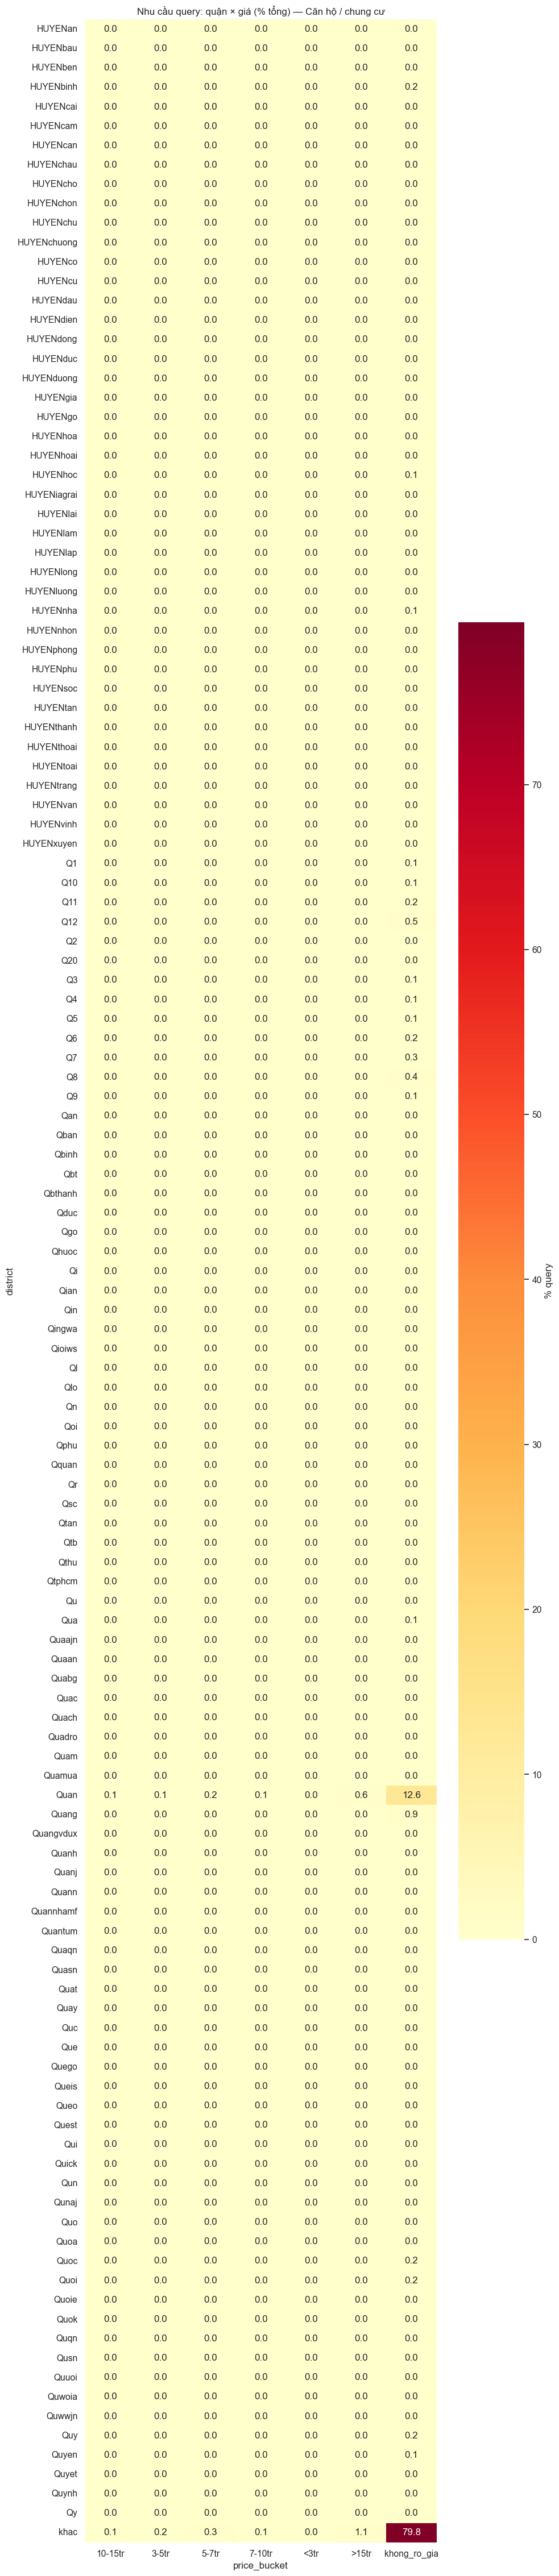

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/query_heatmap_district_price_1020.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,sessions_with_search,search_no_view,pct_unmet
0,66811,0,0.0


<IPython.core.display.Markdown object>


,query,n,price_bucket,district,kw_type,pct
0,mặt bằng,7721,khong_ro_gia,khac,mat bang,40.901626
1,xưởng,1719,khong_ro_gia,khac,khac,9.106320
2,mặt bằng kinh doanh,1626,khong_ro_gia,khac,mat bang,8.613657
3,sang quán,1480,khong_ro_gia,Quan,khac,7.840229
4,mặt+bằng,1187,khong_ro_gia,khac,khac,6.288075
5,cho thuê mặt bằng,1131,khong_ro_gia,khac,mat bang,5.991418
6,kho xưởng,1108,khong_ro_gia,khac,khac,5.869577
7,kho,842,khong_ro_gia,khac,khac,4.460455
8,kiot,575,khong_ro_gia,khac,khac,3.046035
9,thuê mặt bằng,538,khong_ro_gia,khac,mat bang,2.850029


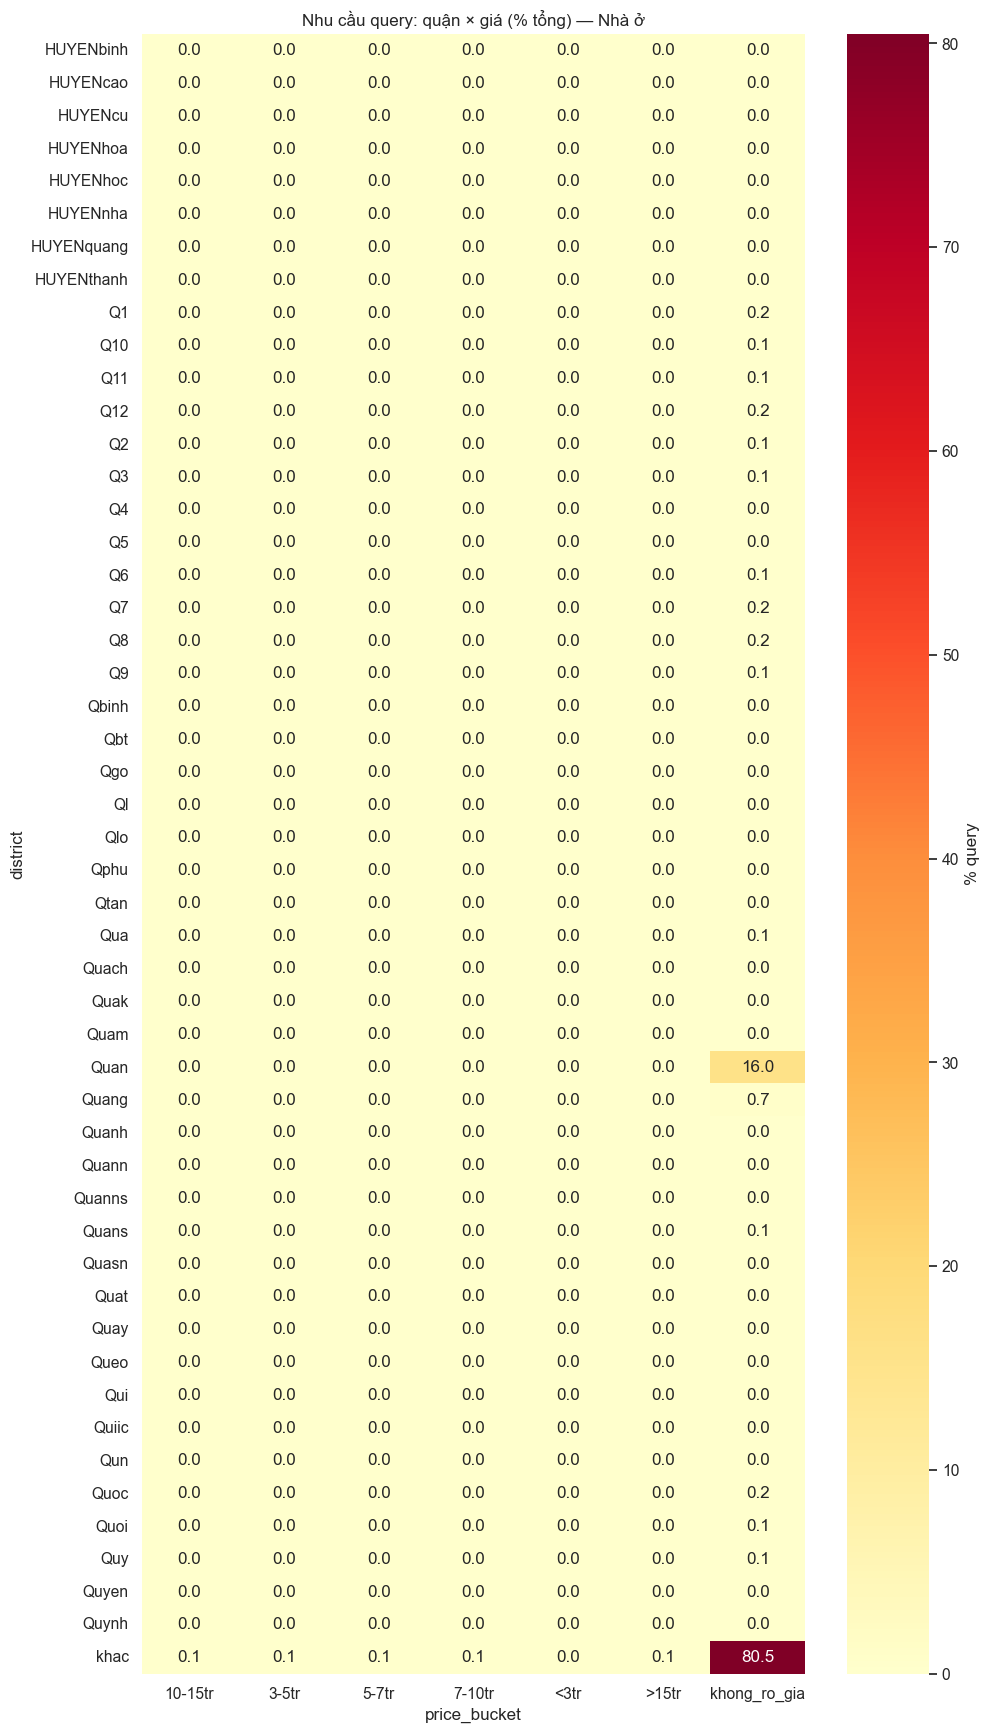

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/query_heatmap_district_price_1030.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,sessions_with_search,search_no_view,pct_unmet
0,21750,0,0.0


<IPython.core.display.Markdown object>


,query,n,price_bucket,district,kw_type,pct
0,đất,1130,khong_ro_gia,khac,khac,31.380172
1,none,388,khong_ro_gia,khac,khac,10.774785
2,bán đất,379,khong_ro_gia,khac,khac,10.524854
3,nhà vườn,295,khong_ro_gia,khac,khac,8.192169
4,đất vườn,255,khong_ro_gia,khac,khac,7.081366
5,giá,185,khong_ro_gia,khac,khac,5.137462
6,vườn,179,khong_ro_gia,khac,khac,4.970841
7,mua bán đất ở bình dương,177,khong_ro_gia,khac,khac,4.915301
8,mặt tiền,159,khong_ro_gia,khac,khac,4.415440
9,mua bán đất ở long an,156,khong_ro_gia,khac,khac,4.332130


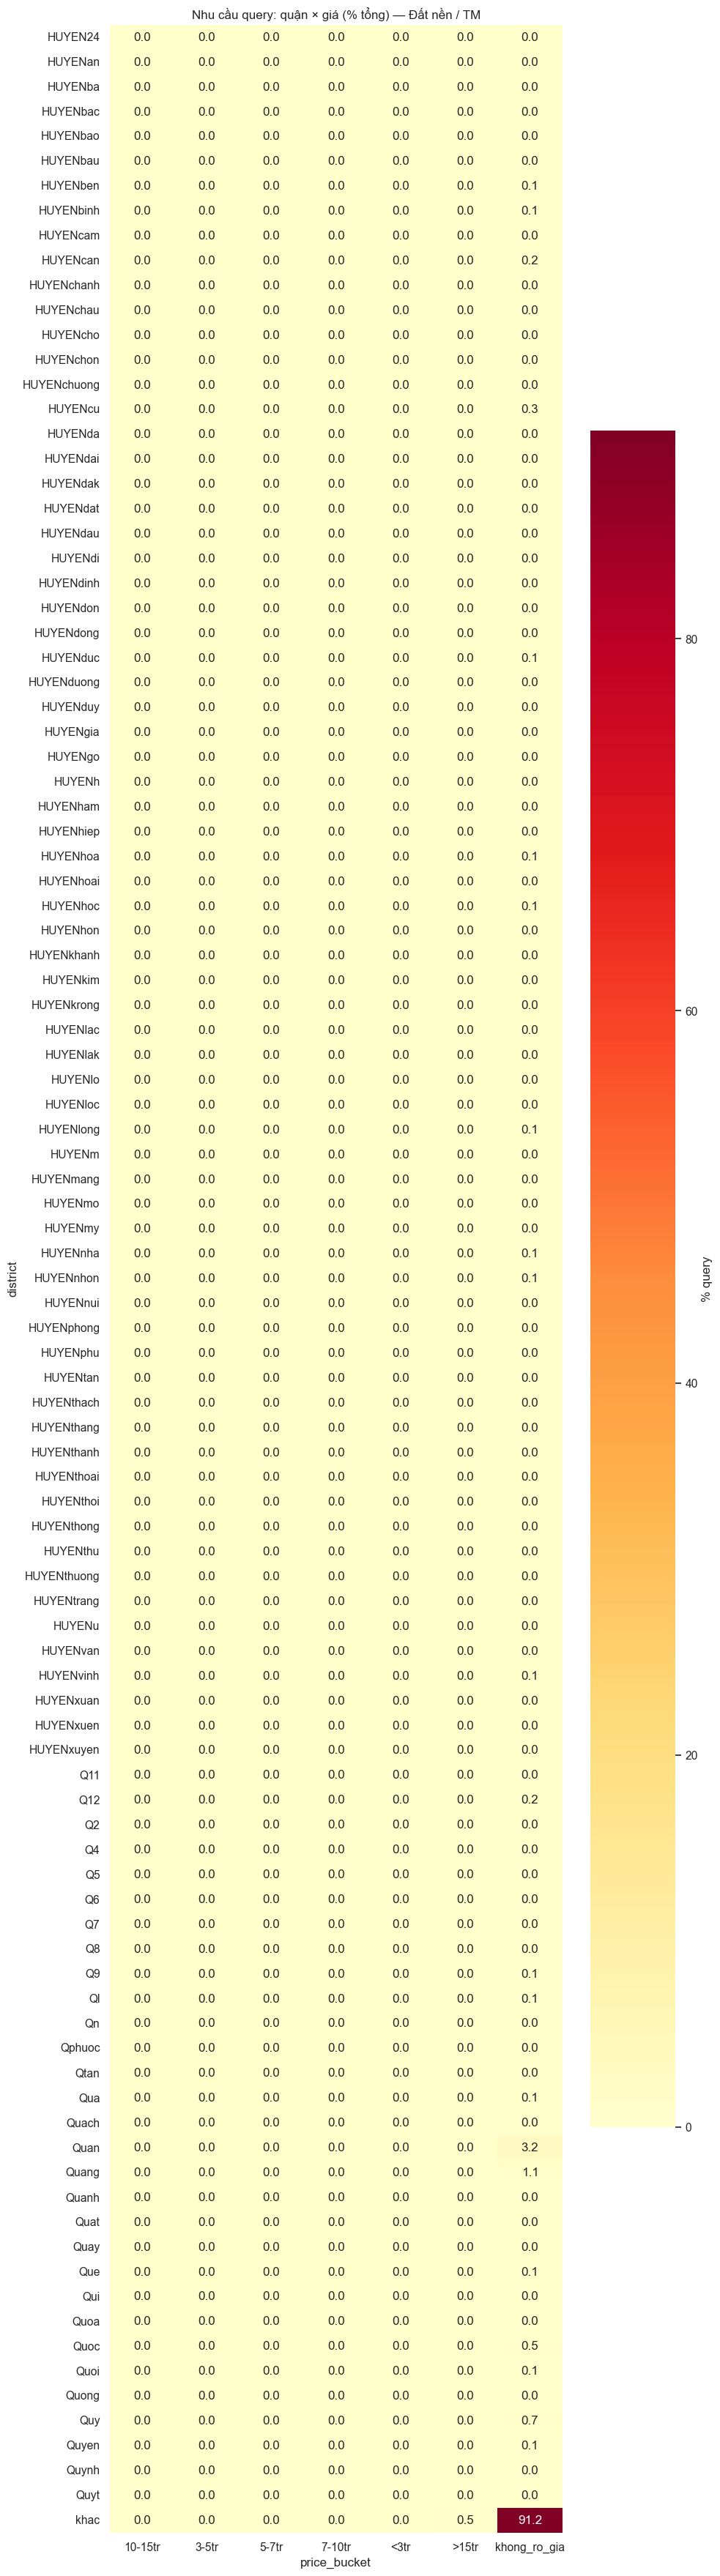

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/query_heatmap_district_price_1040.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,sessions_with_search,search_no_view,pct_unmet
0,15604,0,0.0


<IPython.core.display.Markdown object>


,query,n,price_bucket,district,kw_type,pct
0,phòng trọ,30474,khong_ro_gia,khac,phong tro,32.355814
1,cho thuê phòng trọ ở tp hồ chí minh,17494,khong_ro_gia,khac,phong tro,18.574280
2,trọ,17262,khong_ro_gia,khac,phong tro,18.327954
3,nhà trọ,8676,khong_ro_gia,khac,phong tro,9.211756
4,cho thuê phòng trọ,3693,khong_ro_gia,khac,phong tro,3.921048
5,Cho thuê Phòng trọ ở Tp Hồ Chí Minh,3093,khong_ro_gia,khac,phong tro,3.283997
6,phòng trọ gò vấp,2781,khong_ro_gia,khac,phong tro,2.952731
7,none,2685,khong_ro_gia,khac,khac,2.850803
8,phòng trọ bình thạnh,2359,khong_ro_gia,khac,phong tro,2.504672
9,phòng trọ quận 7,2011,khong_ro_gia,Quan,phong tro,2.135182


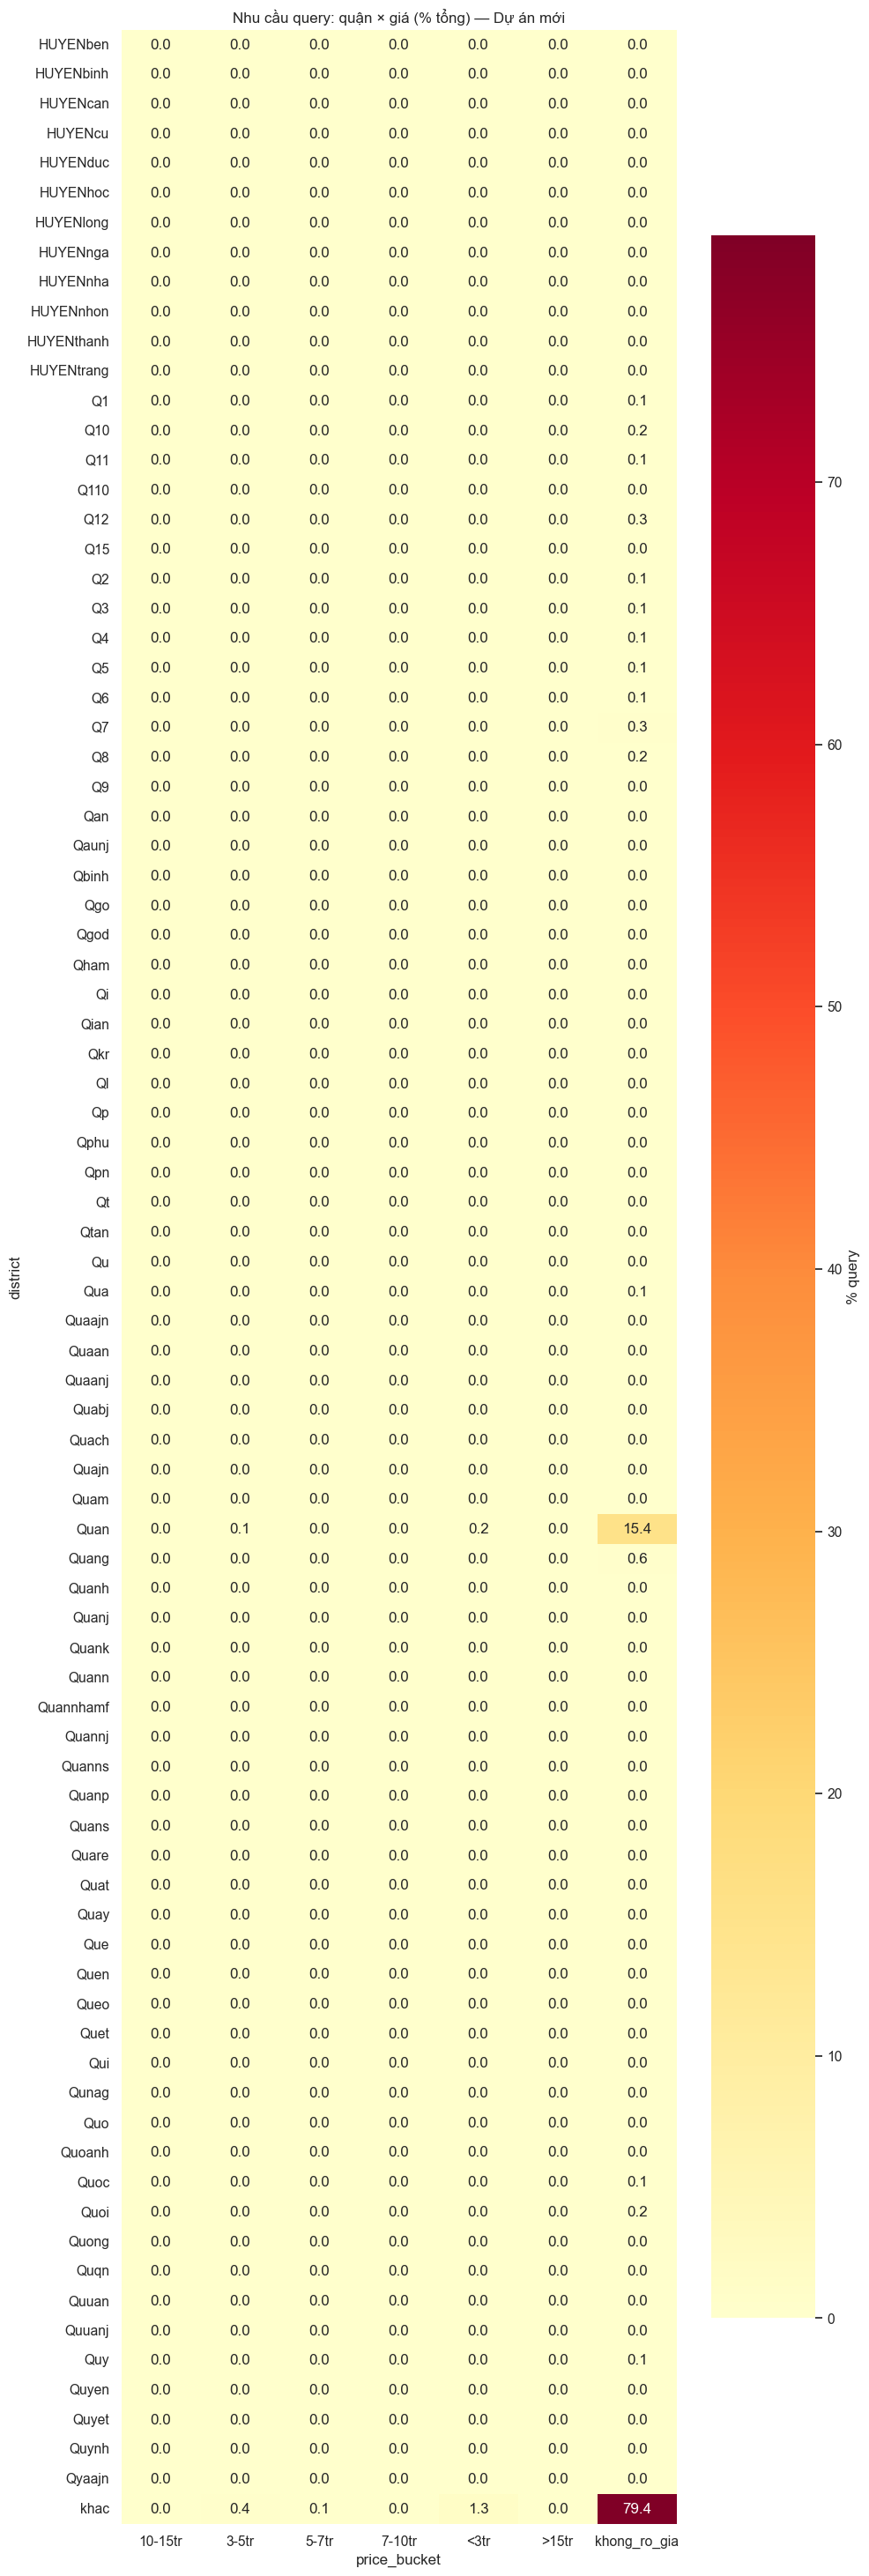

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/query_heatmap_district_price_1050.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,sessions_with_search,search_no_view,pct_unmet
0,83684,0,0.0


In [3]:
PRICE_RE = re.compile(r"(\d+(?:[.,]\d+)?)\s*(tr|trieu|ty|trieu|t)\b", re.I)
DIST_RE = re.compile(r"\b(q|quan|quận|huyen|huyện)\s*([0-9]+|[a-zA-Z]+)", re.I)
KEYWORDS = {
    "phong tro": ["phong tro", "ptro", "tro"],
    "nha nguyen can": ["nha nguyen can", "nguyen can"],
    "chung cu": ["chung cu", "cc", "can ho"],
    "mat bang": ["mat bang", "mb"],
    "homestay": ["homestay"],
}


def price_bucket_vnd(text: str) -> str:
    m = PRICE_RE.search(text)
    if not m:
        return "khong_ro_gia"
    val = float(m.group(1).replace(",", "."))
    unit = m.group(2).lower()
    if unit in ("ty", "t"):
        val *= 1_000_000_000
    else:
        val *= 1_000_000
    if val < 3e6:
        return "<3tr"
    if val < 5e6:
        return "3-5tr"
    if val < 7e6:
        return "5-7tr"
    if val < 10e6:
        return "7-10tr"
    if val < 15e6:
        return "10-15tr"
    return ">15tr"


def extract_district(text: str) -> str:
    m = DIST_RE.search(text)
    if not m:
        return "khac"
    return f"{m.group(1).upper()}{m.group(2)}"


def extract_keyword(text: str) -> str:
    for label, kws in KEYWORDS.items():
        if any(k in text for k in kws):
            return label
    return "khac"


def query_nlp_for_category(cat: int, limit_rows: int = 200_000):
    where_sample = sample_clause(QUERY_SAMPLE_FRAC)
    raw = con.execute(
        f"""
        SELECT query, COUNT(*)::BIGINT AS n
        FROM read_parquet(?)
        WHERE event_type = 'pageview'
          AND category = ?
          AND query IS NOT NULL AND TRIM(CAST(query AS VARCHAR)) <> ''
          {where_sample}
        GROUP BY 1
        ORDER BY n DESC
        LIMIT {limit_rows}
        """,
        [EVENTS_GLOB, cat],
    ).fetchdf()
    if raw.empty:
        return raw, pd.DataFrame(), pd.DataFrame()
    raw["q_norm"] = raw["query"].map(norm_query)
    raw["price_bucket"] = raw["q_norm"].map(price_bucket_vnd)
    raw["district"] = raw["q_norm"].map(extract_district)
    raw["kw_type"] = raw["q_norm"].map(extract_keyword)
    heat = raw.groupby(["district", "price_bucket"], as_index=False)["n"].sum()
    heat_p = heat.pivot_table(index="district", columns="price_bucket", values="n", fill_value=0)
    heat_pct = heat_p / heat_p.values.sum() * 100 if heat_p.values.sum() else heat_p
    return raw, heat, heat_pct


for cat in CATEGORIES_TO_RUN:
    name = CAT_META.loc[CAT_META["category"] == cat, "category_name"].iloc[0]
    print(Markdown(f"### NLP query — {name} ({cat})"))
    raw, heat, heat_pct = query_nlp_for_category(cat)
    if raw.empty:
        continue
    top = raw.nlargest(12, "n")[["query", "n", "price_bucket", "district", "kw_type"]]
    top["pct"] = pct_share(top["n"])
    display(top)
    if not heat_pct.empty and heat_pct.shape[0] > 1:
        fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(heat_pct))))
        sns.heatmap(heat_pct, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "% query"})
        ax.set_title(f"Nhu cầu query: quận × giá (% tổng) — {name}")
        show_and_save(f"query_heatmap_district_price_{cat}.png", dpi=150)
  # Unmet: session search nhưng không pageview
    unmet = con.execute(
        f"""
        WITH sess AS (
            SELECT session_id,
                MAX(CASE WHEN query IS NOT NULL AND TRIM(CAST(query AS VARCHAR)) <> '' THEN 1 ELSE 0 END) AS has_search,
                MAX(CASE WHEN event_type = 'pageview' THEN 1 ELSE 0 END) AS has_view
            FROM read_parquet(?)
            WHERE category = ? AND session_id IS NOT NULL {sample_clause(FUNNEL_SAMPLE_FRAC)}
            GROUP BY session_id
        )
        SELECT
            COUNT(*) FILTER (WHERE has_search = 1) AS sessions_with_search,
            COUNT(*) FILTER (WHERE has_search = 1 AND has_view = 0) AS search_no_view,
            COUNT(*) FILTER (WHERE has_search = 1 AND has_view = 0) * 100.0
                / NULLIF(COUNT(*) FILTER (WHERE has_search = 1), 0) AS pct_unmet
        FROM sess
        """,
        [EVENTS_GLOB, cat],
    ).fetchdf()
    display(unmet)



## Mũi 3 — Lead scoring (`fact_post_contact_interactions`, **login only**)

Rule-based segments:
- **A High-intent:** views ≤ 10 và (leads ≥ 2 hoặc avg chat turns > 5)
- **B Window shopper:** views > 50 và leads = 0 và messages = 0
- **C Spam/broker:** items ≥ 15 và avg turns ≤ 1.5 và messages > 0

<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,segment,users,pct
2,D_other,504925,89.830560
0,A_high_intent,34107,6.067933
1,C_spam_broker,23054,4.101508


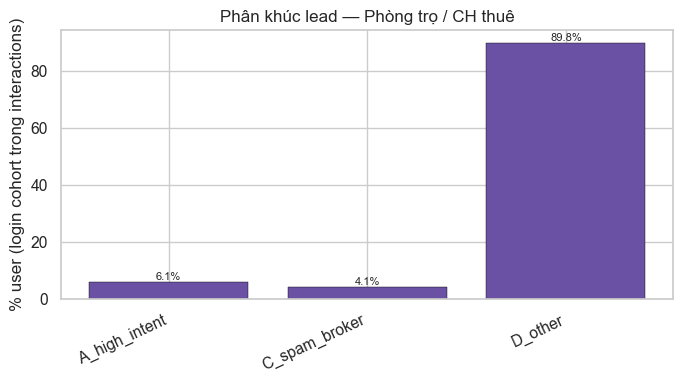

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/lead_segments_1010.png
<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,segment,users,pct
2,D_other,812157,88.449739
0,A_high_intent,58475,6.368348
1,C_spam_broker,47581,5.181913


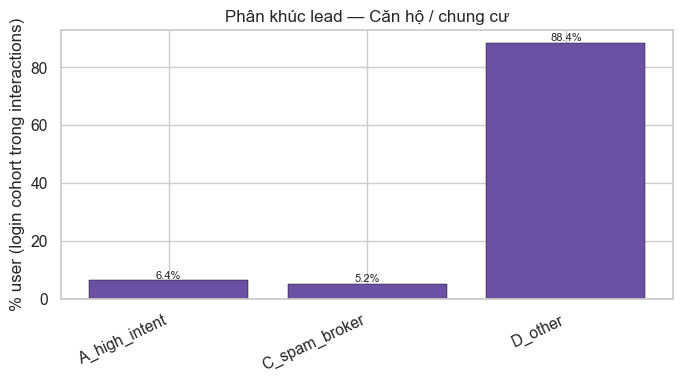

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/lead_segments_1020.png
<IPython.core.display.Markdown object>


,segment,users,pct
2,D_other,177365,90.348987
0,A_high_intent,10493,5.345090
1,C_spam_broker,8453,4.305923


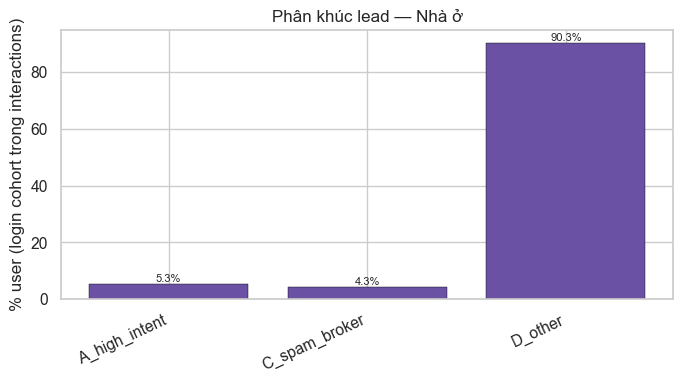

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/lead_segments_1030.png
<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,segment,users,pct
2,D_other,298966,89.873231
0,A_high_intent,23129,6.952891
1,C_spam_broker,10558,3.173878


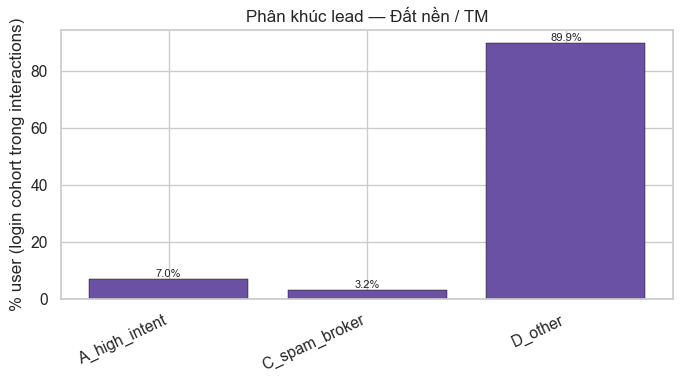

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/lead_segments_1040.png
<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,segment,users,pct
2,D_other,526039,86.148482
1,C_spam_broker,46101,7.549880
0,A_high_intent,38479,6.301638


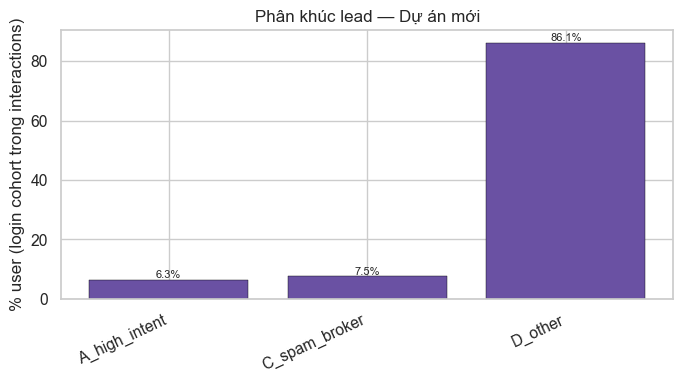

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/lead_segments_1050.png


In [4]:
def lead_profiles_for_category(cat: int) -> pd.DataFrame:
    return con.execute(
        f"""
        SELECT
            user_id,
            SUM(adview_count) AS total_viewed_items,
            SUM(lead_count) AS total_leads,
            SUM(chat_message_count) AS total_messages,
            AVG(chat_turn_count) AS avg_chat_turns,
            MAX(chat_lead) AS has_converted_via_chat,
            SUM(CASE WHEN purchased THEN 1 ELSE 0 END) AS interact_with_hot_items,
            COUNT(DISTINCT item_id) AS distinct_items
        FROM read_parquet(?)
        WHERE category = ?
        GROUP BY user_id
        HAVING SUM(adview_count) > 0
        """,
        [INTER_GLOB, cat],
    ).fetchdf()


def assign_segment(row) -> str:
    v, l, m, t, items = (
        row["total_viewed_items"], row["total_leads"], row["total_messages"],
        row["avg_chat_turns"] or 0, row["distinct_items"],
    )
    if items >= 15 and m > 0 and t <= 1.5:
        return "C_spam_broker"
    if v > 50 and l == 0 and m == 0:
        return "B_window_shopper"
    if v <= 10 and (l >= 2 or t > 5):
        return "A_high_intent"
    return "D_other"


for cat in CATEGORIES_TO_RUN:
    name = CAT_META.loc[CAT_META["category"] == cat, "category_name"].iloc[0]
    print(Markdown(f"### Lead scoring — {name} ({cat})"))
    prof = lead_profiles_for_category(cat)
    if prof.empty:
        print("Không có interaction cho category", cat)
        continue
    prof["segment"] = prof.apply(assign_segment, axis=1)
    seg = prof.groupby("segment").size().reset_index(name="users")
    seg["pct"] = pct_share(seg["users"])
    display(seg.sort_values("users", ascending=False))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(seg["segment"], seg["pct"], color="#6a51a3", edgecolor="black", linewidth=0.3)
    ax.set_ylabel("% user (login cohort trong interactions)")
    ax.set_title(f"Phân khúc lead — {name}")
    plt.xticks(rotation=25, ha="right")
    for i, p in enumerate(seg["pct"]):
        ax.text(i, p, f"{p:.1f}%", ha="center", va="bottom", fontsize=8)
    show_and_save(f"lead_segments_{cat}.png", dpi=150)



## Mũi 4 — Độ tươi tin (`listing_age_days` khi contact)

Join `fact_user_events` (contact) với `fact_listing_snapshot` theo `item_id` + `date`.

<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pct_contacts
listing_age_days,
0,8.544535
1,9.449907
2,5.180392
3,3.932290
4,3.334238
5,2.971966
6,2.707353
7,2.458205
8,2.206776


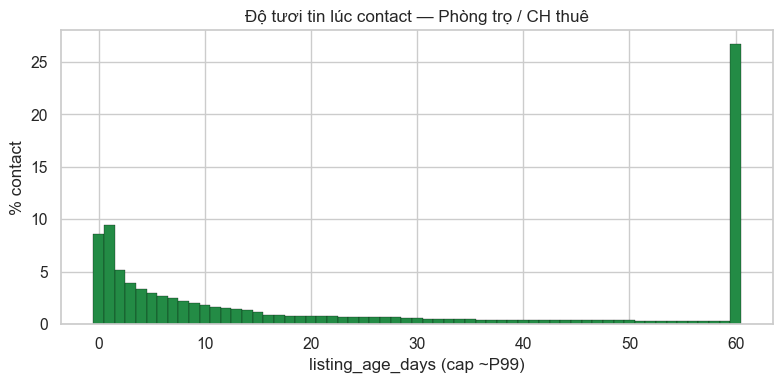

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/listing_age_at_contact_1010.png
% contact khi tin ≤ 2 ngày: 23.2%
<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pct_contacts
listing_age_days,
0,11.111940
1,10.968324
2,6.395315
3,4.807649
4,3.983476
5,3.619193
6,3.325555
7,2.884235
8,2.462004


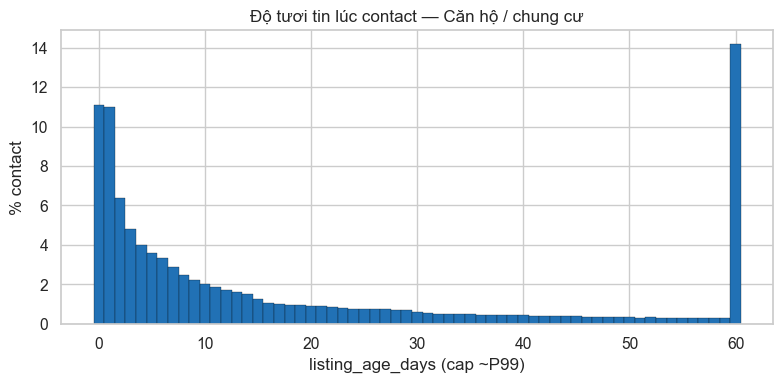

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/listing_age_at_contact_1020.png
% contact khi tin ≤ 2 ngày: 28.5%
<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pct_contacts
listing_age_days,
0,10.502316
1,10.963518
2,6.431449
3,4.768314
4,3.930505
5,3.543739
6,3.231821
7,2.961191
8,2.566740


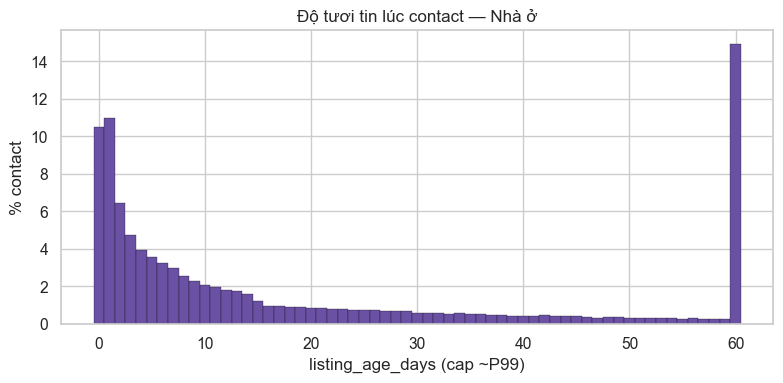

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/listing_age_at_contact_1030.png
% contact khi tin ≤ 2 ngày: 27.9%
<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pct_contacts
listing_age_days,
0,8.247299
1,8.103339
2,4.856290
3,3.704208
4,3.191267
5,2.902858
6,2.624942
7,2.424016
8,2.114265


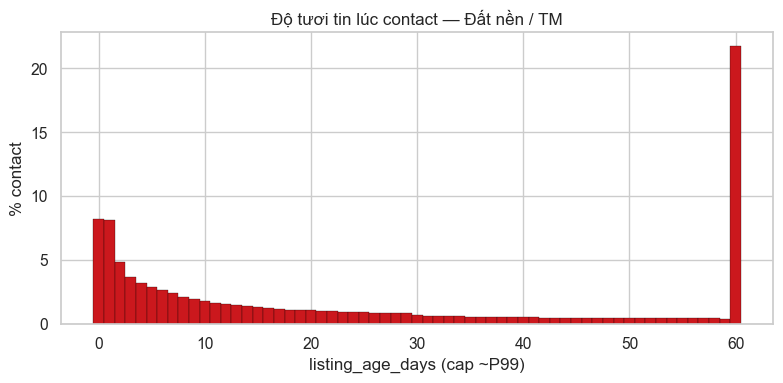

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/listing_age_at_contact_1040.png
% contact khi tin ≤ 2 ngày: 21.2%
<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pct_contacts
listing_age_days,
0,8.588355
1,9.692597
2,5.741772
3,4.376451
4,3.691732
5,3.256100
6,2.934291
7,2.669647
8,2.395829


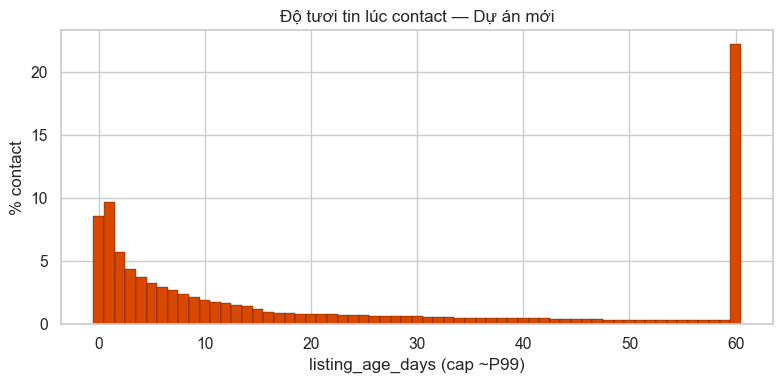

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_deep/listing_age_at_contact_1050.png
% contact khi tin ≤ 2 ngày: 24.0%


In [5]:
def listing_age_at_contact(cat: int) -> pd.DataFrame:
    where_sample = sample_clause(LISTING_AGE_SAMPLE_FRAC)
    return con.execute(
        f"""
        SELECT s.listing_age_days
        FROM read_parquet(?) e
        INNER JOIN read_parquet(?) s
            ON e.item_id = s.item_id AND e.date = s.date
        WHERE e.category = ?
          AND (e.is_contact = 1 OR e.event_type IN ({pos_list}))
          AND s.listing_age_days IS NOT NULL
          {where_sample}
        """,
        [EVENTS_GLOB, SNAP_GLOB, cat],
    ).fetchdf()


for cat in CATEGORIES_TO_RUN:
    name = CAT_META.loc[CAT_META["category"] == cat, "category_name"].iloc[0]
    print(Markdown(f"### Listing age — {name} ({cat})"))
    ages = listing_age_at_contact(cat)
    if ages.empty:
        print("Không join được snapshot")
        continue
    cap = min(60, int(ages["listing_age_days"].quantile(0.99)) + 1)
    ages_cap = ages["listing_age_days"].clip(upper=cap)
    hist = ages_cap.value_counts().sort_index()
    hist_pct = pct_share(hist)
    display(hist_pct.head(10).to_frame("pct_contacts"))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(hist_pct.index.astype(int), hist_pct.values, width=1.0, color=PALETTE.get(cat, "#333"), edgecolor="black", linewidth=0.2)
    ax.set_xlabel("listing_age_days (cap ~P99)")
    ax.set_ylabel("% contact")
    ax.set_title(f"Độ tươi tin lúc contact — {name}")
    show_and_save(f"listing_age_at_contact_{cat}.png", dpi=150)
    young = (ages["listing_age_days"] <= 2).mean() * 100
    print(f"% contact khi tin ≤ 2 ngày: {young:.1f}%")

